# 08 — Clustering Socioeconômico e Análise de Desempenho

Neste notebook, aplicaremos técnicas de **Aprendizado de Máquina Não Supervisionado** (Clustering) para identificar grupos (personas) de estudantes com perfis socioeconômicos similares. Em seguida, analisaremos se esses grupos diferem significativamente em termos de desempenho acadêmico (ANOVA).

**Objetivos:**
1. Agrupar alunos baseando-se em Renda (`Q006`), Escolaridade dos Pais (`Q001`, `Q002`) e Bens/Serviços.
2. Caracterizar os clusters encontrados.
3. Testar a hipótese de que o perfil socioeconômico impacta significativamente a nota média.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from scipy import stats

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Carregamento e Preparação dos Dados

In [2]:
DATA_PATH = Path("../data/interim/enem_2023.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {DATA_PATH}")

# Carregar colunas relevantes para economizar memória
COLS = [
    "Q001_ord", "Q002_ord", "Q006_ord", 
    "Q022_ord", "Q024_ord", "Q025_ord", 
    "TP_ESCOLA", "NOTA_MEDIA_5", "IN_TREINEIRO"
]

df = pd.read_parquet(DATA_PATH, columns=COLS)

# Filtrar treineiros e remover NaNs
if "IN_TREINEIRO" in df.columns:
    df = df[df["IN_TREINEIRO"] == 0].copy()
    
df = df.dropna().copy()

print(f"Dados carregados: {df.shape[0]} registros.")
df.head()

Dados carregados: 2166843 registros.


,Q001_ord,Q002_ord,Q006_ord,Q022_ord,Q024_ord,Q025_ord,TP_ESCOLA,NOTA_MEDIA_5,IN_TREINEIRO
0,8,5,3,1,1,2,1,507.94,0
1,4,4,3,4,1,2,2,564.28,0
2,2,2,2,2,1,1,2,425.38,0
3,8,5,6,3,2,2,1,617.12,0
4,6,3,2,5,2,2,1,697.66,0


## 2. Seleção de Features e Escalonamento

Usaremos as features ordinais socioeconômicas para o clustering. O desempenho não entra no clustering, pois queremos usá-lo depois para validação.

In [3]:
FEATURES = ["Q001_ord", "Q002_ord", "Q006_ord", "Q022_ord", "Q024_ord", "Q025_ord"]
X = df[FEATURES].values

# Padronização (média=0, desvio=1) é crucial para K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features escalonadas. Exemplo:")
print(X_scaled[:3])

Features escalonadas. Exemplo:
[[ 1.81511406  0.20657432 -0.44559338 -2.29839194 -0.79896946  0.31144048]
 [-0.24838625 -0.39586162 -0.44559338  0.44012972 -0.79896946  0.31144048]
 [-1.28013641 -1.60073352 -0.73290597 -1.38555139 -0.79896946 -3.21088644]]


## 3. Determinação do Número de Clusters (Elbow Method)
Usaremos uma amostra para agilizar a decisão do K.

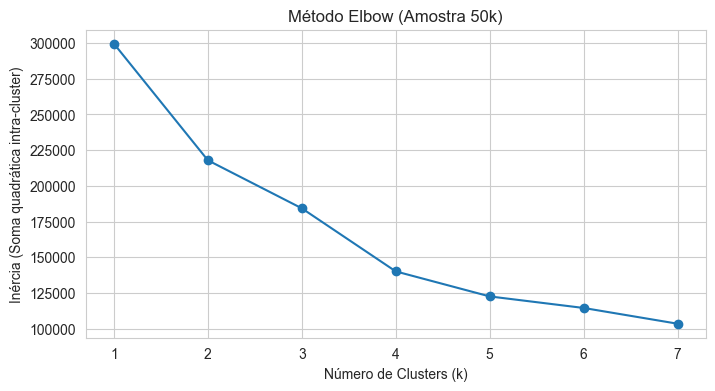

In [4]:
# Amostra de 50k para o Elbow Method
sample_idx = np.random.choice(X_scaled.shape[0], 50000, replace=False)
X_sample = X_scaled[sample_idx]

inertias = []
K_range = range(1, 8)

for k in K_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3)
    kmeans.fit(X_sample)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o')
plt.title('Método Elbow (Amostra 50k)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (Soma quadrática intra-cluster)')
plt.show()

## 4. Clustering (K-Means)
Assumindo K=3 ou K=4 como um bom ponto de partida (baseado em experiências comuns com estratificação social: Baixa, Média, Alta renda). Vamos fixar K=3 para interpretar facilmente: Baixo, Médio e Alto perfil socioeconômico.

In [5]:
K = 3
kmeans = MiniBatchKMeans(n_clusters=K, random_state=42, batch_size=2048, n_init=3)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Tamanhos dos Clusters:")
print(df["cluster"].value_counts(normalize=True).sort_index())

Tamanhos dos Clusters:
cluster
0    0.035072
1    0.911525
2    0.053403
Name: proportion, dtype: float64


## 5. Caracterização dos Clusters (Profiling)
Vamos olhar a média das variáveis originais em cada cluster para dar nomes a eles.

   cluster  Q001_ord  Q002_ord  Q006_ord  Q022_ord  Q024_ord  Q025_ord
0        0  5.746760  5.148615  2.346483  2.616133  1.099664  1.000000
1        1  4.559576  4.740891  4.788058  3.623987  1.764470  1.999997
2        2  2.317622  2.904127  1.950638  2.298334  1.044488  1.001098


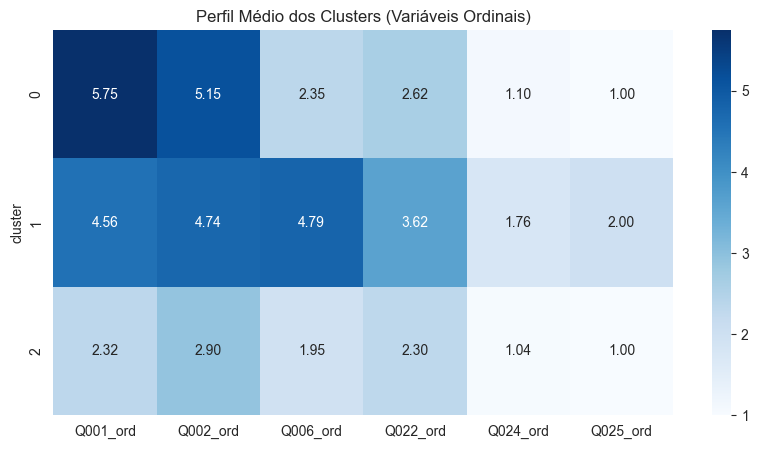

In [6]:
profile = df.groupby("cluster")[FEATURES].mean().reset_index()
print(profile)

# Visualização com Heatmap (padronizado por coluna para ver diferenças relativas)
plt.figure(figsize=(10, 5))
sns.heatmap(profile.set_index("cluster"), annot=True, cmap="Blues", fmt=".2f")
plt.title("Perfil Médio dos Clusters (Variáveis Ordinais)")
plt.show()

## 6. Visualização com PCA
Reduzir para 2 dimensões para visualizar a separação espacial dos clusters.

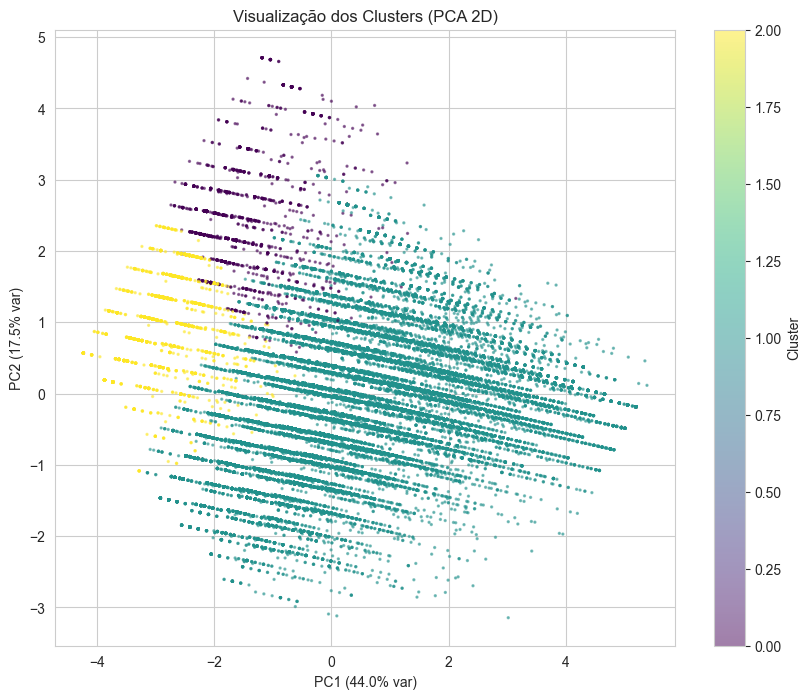

In [7]:
# PCA na amostra (para performance visual)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
clusters_sample = kmeans.predict(X_sample)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_sample, cmap='viridis', alpha=0.5, s=2)
plt.title("Visualização dos Clusters (PCA 2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
plt.colorbar(scatter, label="Cluster")
plt.show()

## 7. Análise de Desempenho por Cluster
A pergunta central: **Existem diferenças significativas de nota entre os grupos?**

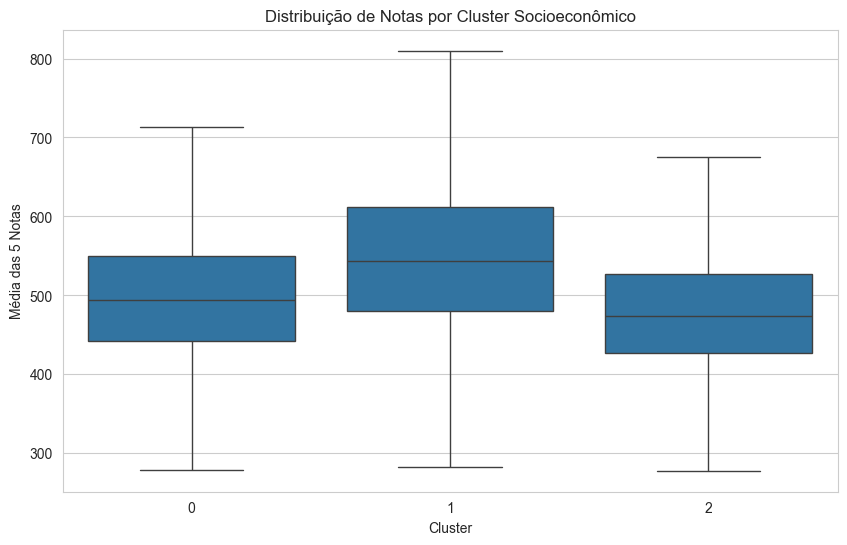

Médias de Notas por Cluster:
               mean        std    count
cluster                                
0        495.354839  84.232589    75995
1        546.023964  96.093116  1975132
2        476.004651  78.422388   115716

Resultado ANOVA: F=38718.97, p-value=0.0
Conclusão: Existem diferenças estatisticamente significativas entre as médias dos clusters.


In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="cluster", y="NOTA_MEDIA_5", data=df, showfliers=False)
plt.title("Distribuição de Notas por Cluster Socioeconômico")
plt.ylabel("Média das 5 Notas")
plt.xlabel("Cluster")
plt.show()

print("Médias de Notas por Cluster:")
print(df.groupby("cluster")["NOTA_MEDIA_5"].agg(["mean", "std", "count"]))

# Teste ANOVA (One-way)
cluster_groups = [df[df["cluster"] == k]["NOTA_MEDIA_5"] for k in range(K)]
f_stat, p_val = stats.f_oneway(*cluster_groups)

print(f"\nResultado ANOVA: F={f_stat:.2f}, p-value={p_val}")
if p_val < 0.05:
    print("Conclusão: Existem diferenças estatisticamente significativas entre as médias dos clusters.")
else:
    print("Conclusão: NÃO existem diferenças estatisticamente significativas.")